# Employee Attrition Prediction

Predict whether an employee will **leave** the company from HR attributes (role, income, satisfaction, overtime, tenure and more). The notebook covers five steps:

1. Benchmark six classifiers on one leak-free preprocessing pipeline.
2. Tune the best model with cross-validation.
3. Turn the risk scores into a **retention targeting policy**.
4. Explain individual predictions with **SHAP**.
5. **Audit fairness** across gender and marital status.

| | |
|---|---|
| **Dataset** | [Employee Attrition Classification Dataset](https://www.kaggle.com/datasets/stealthtechnologies/employee-attrition-dataset) (Kaggle, **synthetic**): `train.csv` 59,598 rows, `test.csv` 14,900 rows |
| **Target** | `Attrition`, where *Left* = 1 (positive class) and *Stayed* = 0 |
| **Protocol** | Train on `train.csv`, holding out a stratified 20% validation split for model selection. Tune with 5-fold CV and report the final score **once** on `test.csv`. |
| **Code** | Shared preprocessing, model and explanation code lives in the [`attrition/`](attrition) package. The [demo app](app.py) and the [tests](tests) use the same code. |

## 1. Setup

In [1]:
import sys, os
if "google.colab" in sys.modules and not os.path.exists("attrition"):  # Colab: fetch the repo's package
    !git clone -q https://github.com/RachitSethi2455/employee-attrition-prediction.git
    %cd employee-attrition-prediction
    !pip install -q -r requirements.txt

In [2]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

from attrition.data import FEATURES, NOMINAL, NUMERIC, ORDINAL, load_data, split_xy
from attrition.explain import shap_by_feature
from attrition.pipeline import SEED, build_preprocess, make_pipeline, metrics, model_zoo, scores

ASSETS, MODELS = Path("assets"), Path("models")
ASSETS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

## 2. Load the data
On first use, `load_data()` downloads `train.csv` and `test.csv` into `data/` with `kagglehub`.

In [3]:
train_df, test_df = load_data()
print("train:", train_df.shape, "| test:", test_df.shape)
print("missing values:", train_df.isna().sum().sum() + test_df.isna().sum().sum(),
      "| duplicate rows:", train_df.duplicated().sum())
print("Employee IDs shared by train and test:", len(set(train_df["Employee ID"]) & set(test_df["Employee ID"])))
train_df.head(3).T

Extracting files...


train: (59598, 24) | test: (14900, 24)


missing values: 0 | duplicate rows: 0
Employee IDs shared by train and test: 0


,0,1,2
Employee ID,8410,64756,30257
Age,31,59,24
Gender,Male,Female,Female
Years at Company,19,4,10
Job Role,Education,Media,Healthcare
Monthly Income,5390,5534,8159
Work-Life Balance,Excellent,Poor,Good
Job Satisfaction,Medium,High,High
Performance Rating,Average,Low,Low
Number of Promotions,2,3,0


## 3. Exploratory analysis

### Target balance
The classes are close to balanced, so accuracy is a meaningful metric. ROC-AUC and the F1 score for the *Left* class are reported alongside it.

In [4]:
balance = pd.concat({"train": train_df["Attrition"].value_counts(normalize=True),
                     "test": test_df["Attrition"].value_counts(normalize=True)}, axis=1)
balance.style.format("{:.1%}")

,train,test
Attrition,,
Stayed,52.5%,52.8%
Left,47.5%,47.2%


### What separates leavers from stayers?
Attrition rate per category for the categorical features, sorted by how much the rate varies across categories. The dashed line is the overall attrition rate.

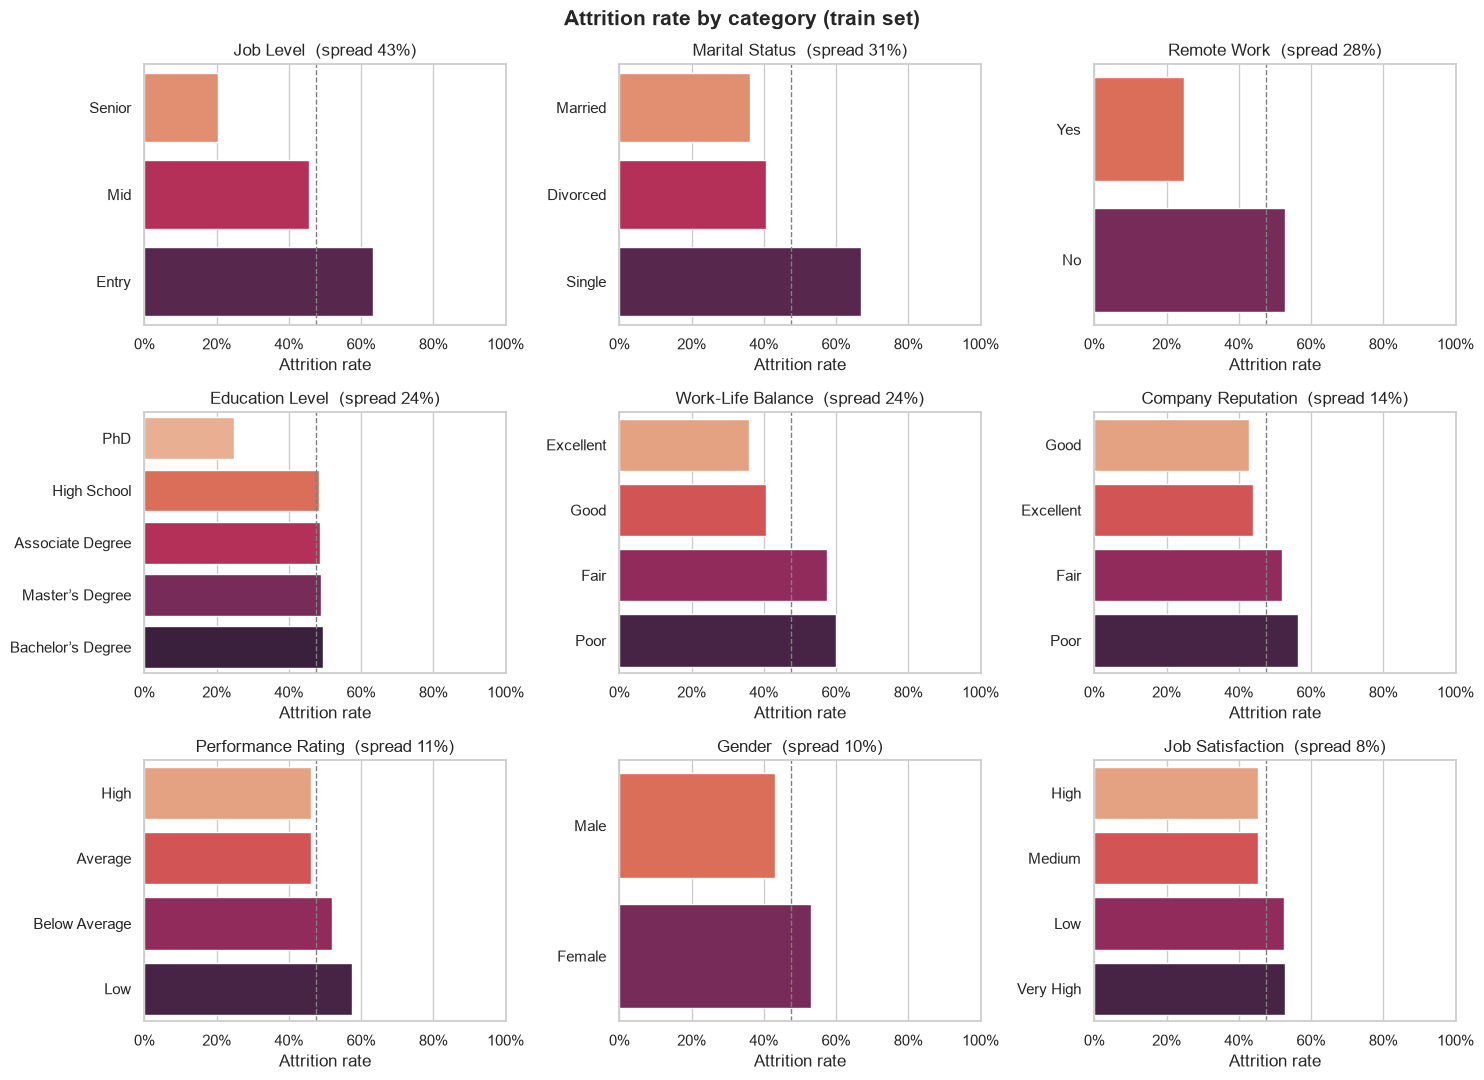

In [5]:
eda = train_df.assign(left=(train_df["Attrition"] == "Left").astype(int))
overall = eda["left"].mean()
cat_cols = list(ORDINAL) + list(NOMINAL)
spread = {c: eda.groupby(c)["left"].mean().agg(lambda s: s.max() - s.min()) for c in cat_cols}
top_cats = sorted(spread, key=spread.get, reverse=True)[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, top_cats):
    rates = eda.groupby(col)["left"].mean().sort_values()
    sns.barplot(x=rates.values, y=rates.index.astype(str), hue=rates.index.astype(str), palette="rocket_r", legend=False, ax=ax)
    ax.axvline(overall, ls="--", color="grey", lw=1)
    ax.set(title=f"{col}  (spread {spread[col]:.0%})", xlabel="Attrition rate", ylabel="", xlim=(0, 1))
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
fig.suptitle("Attrition rate by category (train set)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(ASSETS / "attrition_by_category.png", dpi=110, bbox_inches="tight")
plt.show()

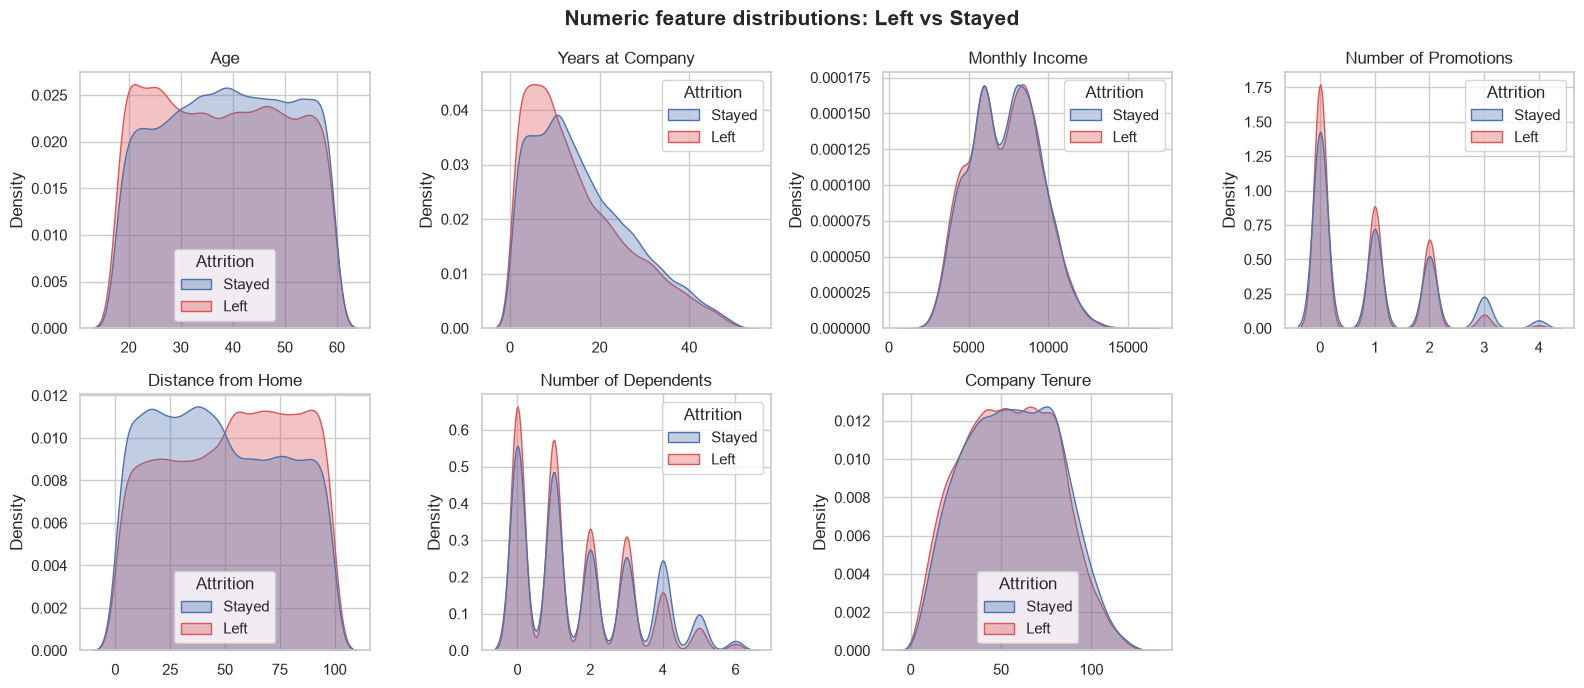

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, NUMERIC):
    sns.kdeplot(data=eda, x=col, hue="Attrition", common_norm=False, fill=True, alpha=0.35, ax=ax,
                palette={"Stayed": "#4C72B0", "Left": "#DD5555"}, warn_singular=False)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.flat[len(NUMERIC):]:
    ax.remove()
fig.suptitle("Numeric feature distributions: Left vs Stayed", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations**
- **Job Level** is the strongest single signal: 63% of entry-level employees left, compared with 20% of senior employees.
- **Single** employees leave at 67%, compared with 36% for married employees. Employees who work **remotely** leave at 25%, compared with 53% for those who don't.
- **Work-Life Balance** (Poor/Fair ≈ 58% vs Good/Excellent ≈ 38%) and **Education** (PhD 25% vs ≈ 48% for every other level) also separate the groups clearly.
- Job Satisfaction, Overtime, Job Role, Company Size and Employee Recognition barely move the rate (≤ 8 points).
- Among numeric features, leavers live slightly **farther from home** (53 vs 47), have **fewer dependents and promotions**, and have slightly shorter tenure. **Monthly Income is almost identical** in both groups.

## 4. Preprocessing pipeline

Every step lives inside a scikit-learn `Pipeline` ([`attrition/pipeline.py`](attrition/pipeline.py)), so it is fit on training folds only:

| Feature type | Columns | Encoding |
|---|---|---|
| Ordered categories | Work-Life Balance, Job Satisfaction, Performance Rating, Education Level, Job Level, Company Size, Company Reputation, Employee Recognition | `OrdinalEncoder` with the **real** order (Poor < Fair < Good < Excellent, …) |
| Nominal / binary | Gender, Job Role, Marital Status, Overtime, Remote Work, Leadership & Innovation Opportunities | `OneHotEncoder` (a single column for binary features) |
| Numeric | Age, Income, Tenure, Distance, … | `StandardScaler` |

In [7]:
X_full, y_full = split_xy(train_df)
X_test, y_test = split_xy(test_df)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, stratify=y_full, random_state=SEED)
print(f"train {len(X_train):,} | validation {len(X_val):,} | test {len(X_test):,}")
print("encoded feature count:", build_preprocess().fit(X_train).transform(X_train.head()).shape[1])

train 47,678 | validation 11,920 | test 14,900


encoded feature count: 28


## 5. Model comparison

Each model is fit on the training split and scored on the validation split, which is used for model selection. The test set is not touched until section 7.

In [8]:
fitted, rows = {}, []
for name, clf in model_zoo().items():
    start = time.time()
    pipe = make_pipeline(clf).fit(X_train, y_train)
    fitted[name] = pipe
    rows.append({"Model": name, **metrics(y_val, pipe.predict(X_val), scores(pipe, X_val)),
                 "Fit time (s)": time.time() - start})

val_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
val_results.style.format({c: "{:.3f}" for c in val_results.columns[1:-1]} | {"Fit time (s)": "{:.1f}"}) \
           .highlight_max(subset=val_results.columns[1:-1], color="#c7e9c0")

,Model,Accuracy,ROC-AUC,Precision (Left),Recall (Left),F1 (Left),Fit time (s)
0,Hist. Gradient Boosting,0.755,0.849,0.742,0.745,0.743,5.6
1,Random Forest,0.745,0.837,0.737,0.721,0.729,28.5
2,SVM (RBF),0.744,0.836,0.734,0.725,0.729,749.0
3,Logistic Regression,0.738,0.828,0.727,0.719,0.723,1.3
4,KNN (k=15),0.706,0.779,0.687,0.702,0.695,13.4
5,Decision Tree,0.664,0.663,0.646,0.647,0.647,2.3


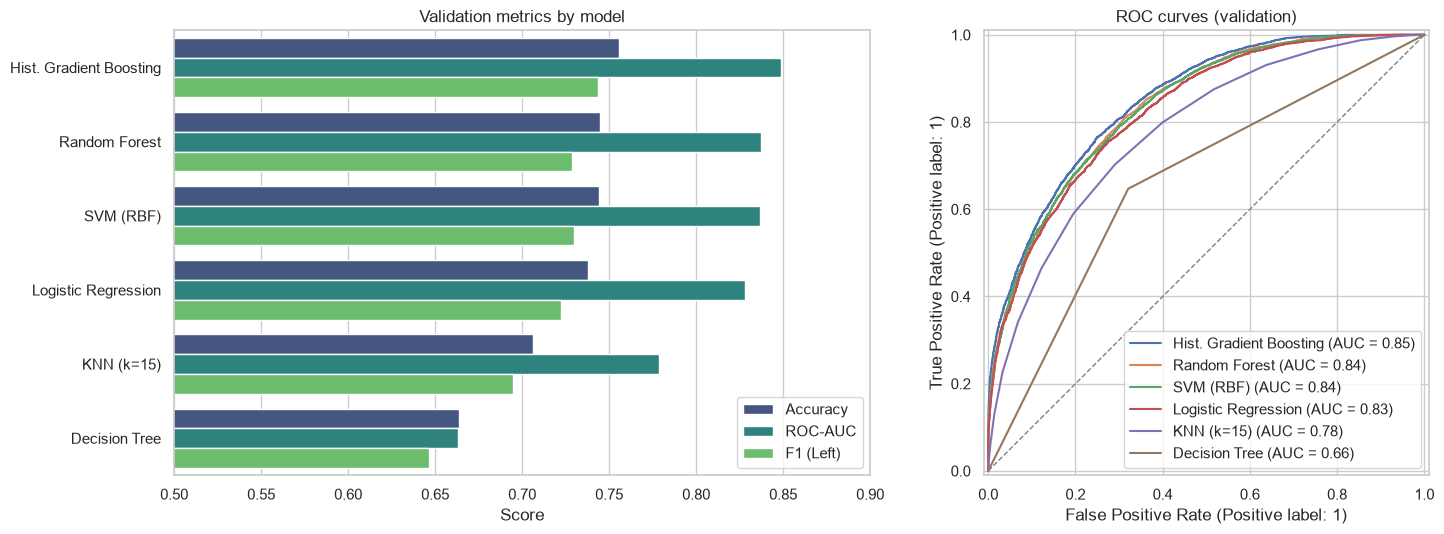

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
melted = val_results.melt(id_vars="Model", value_vars=["Accuracy", "ROC-AUC", "F1 (Left)"], var_name="Metric")
sns.barplot(data=melted, y="Model", x="value", hue="Metric", palette="viridis", ax=axes[0])
axes[0].set(xlim=(0.5, 0.9), xlabel="Score", ylabel="", title="Validation metrics by model")
axes[0].legend(loc="lower right")
for name in val_results["Model"]:
    RocCurveDisplay.from_predictions(y_val, scores(fitted[name], X_val), name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
axes[1].set_title("ROC curves (validation)")
plt.tight_layout()
plt.savefig(ASSETS / "model_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

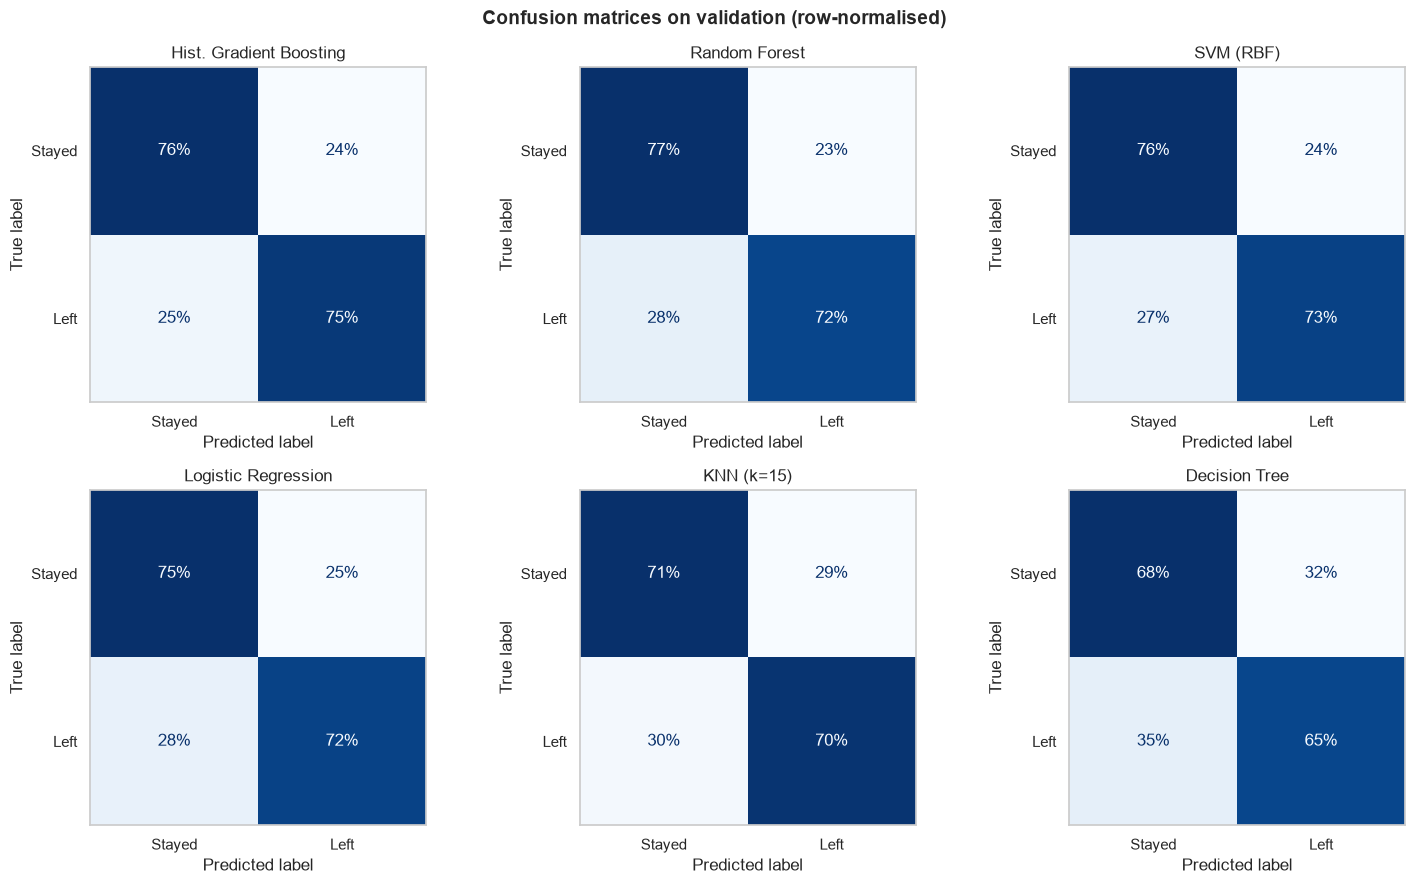

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.flat, val_results["Model"]):
    ConfusionMatrixDisplay.from_predictions(y_val, fitted[name].predict(X_val), display_labels=["Stayed", "Left"],
                                            normalize="true", values_format=".0%", cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
    ax.grid(False)
fig.suptitle("Confusion matrices on validation (row-normalised)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the comparison**
- **Gradient boosting** leads (ROC-AUC 0.849), followed by random forest, RBF-SVM and logistic regression, all within about 2 points. The single decision tree (0.66) and KNN (0.78) trail clearly.
- **Logistic regression is only 2 points behind** the best non-linear model. Most of the signal is close to additive, which fits a synthetic dataset.
- RBF-SVM takes about 100× longer to fit than gradient boosting and is no more accurate.

## 6. Tune the best model with 5-fold cross-validation
The model with the best validation ROC-AUC is tuned with a randomized search over 5 stratified folds of the **full** training file.

In [11]:
best_name = val_results.loc[0, "Model"]
print("Selected on validation ROC-AUC:", best_name)

SEARCH_SPACES = {
    "Hist. Gradient Boosting": {
        "clf__learning_rate": [0.02, 0.05, 0.1, 0.2],
        "clf__max_iter": [200, 400, 800],
        "clf__max_leaf_nodes": [15, 31, 63],
        "clf__min_samples_leaf": [20, 50, 100, 200],
        "clf__l2_regularization": [0.0, 0.1, 1.0],
    },
    "Random Forest": {"clf__max_depth": [None, 10, 20], "clf__min_samples_leaf": [1, 5, 20], "clf__max_features": ["sqrt", 0.5]},
    "Logistic Regression": {"clf__C": np.logspace(-3, 2, 12)},
    "SVM (RBF)": {"clf__C": [0.3, 1, 3], "clf__gamma": ["scale", 0.01, 0.1]},
}
search = RandomizedSearchCV(
    fitted[best_name], SEARCH_SPACES.get(best_name, {}), n_iter=20, scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), random_state=SEED, refit=True,  # HistGB is already multi-threaded
)
start = time.time()
search.fit(X_full, y_full)
print(f"search time {time.time() - start:.0f}s | best CV ROC-AUC {search.best_score_:.4f} ± "
      f"{search.cv_results_['std_test_score'][search.best_index_]:.4f}")
pd.Series(search.best_params_).rename("best value").to_frame()

Selected on validation ROC-AUC: Hist. Gradient Boosting


search time 207s | best CV ROC-AUC 0.8495 ± 0.0036


,best value
clf__min_samples_leaf,20.00
clf__max_leaf_nodes,15.00
clf__max_iter,200.00
clf__learning_rate,0.05
clf__l2_regularization,0.10


## 7. Final evaluation on the held-out test set
This is the first and only time `test.csv` is used for evaluation. The later sections analyse these same test predictions; they don't change the model.

In [12]:
final_model = search.best_estimator_
y_pred = final_model.predict(X_test)
y_score = scores(final_model, X_test)
final_metrics = metrics(y_test, y_pred, y_score)
print(pd.Series(final_metrics).round(4).to_string())
print()
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"], digits=3))

Accuracy            0.7603
ROC-AUC             0.8523
Precision (Left)    0.7445
Recall (Left)       0.7493
F1 (Left)           0.7469

              precision    recall  f1-score   support

      Stayed      0.775     0.770     0.772      7868
        Left      0.745     0.749     0.747      7032

    accuracy                          0.760     14900
   macro avg      0.760     0.760     0.760     14900
weighted avg      0.760     0.760     0.760     14900



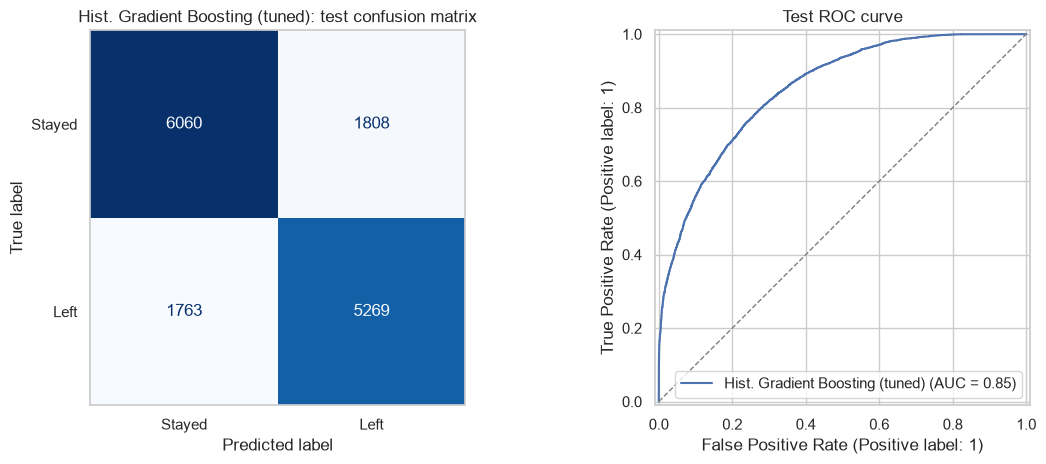

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Stayed", "Left"], cmap="Blues",
                                        colorbar=False, ax=axes[0])
axes[0].set_title(f"{best_name} (tuned): test confusion matrix")
axes[0].grid(False)
RocCurveDisplay.from_predictions(y_test, y_score, name=f"{best_name} (tuned)", ax=axes[1])
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
axes[1].set_title("Test ROC curve")
plt.tight_layout()
plt.savefig(ASSETS / "final_test_results.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. From scores to a retention policy

An HR team rarely acts on a hard 0.5 cut-off. It usually has budget to reach out to a **fixed share of employees**, and it wants the people most likely to leave. The left plot shows how precision and recall trade off as the threshold moves. The right plot is a **capture curve**: if HR contacts the top *k%* of employees ranked by risk, what share of actual leavers does it reach?

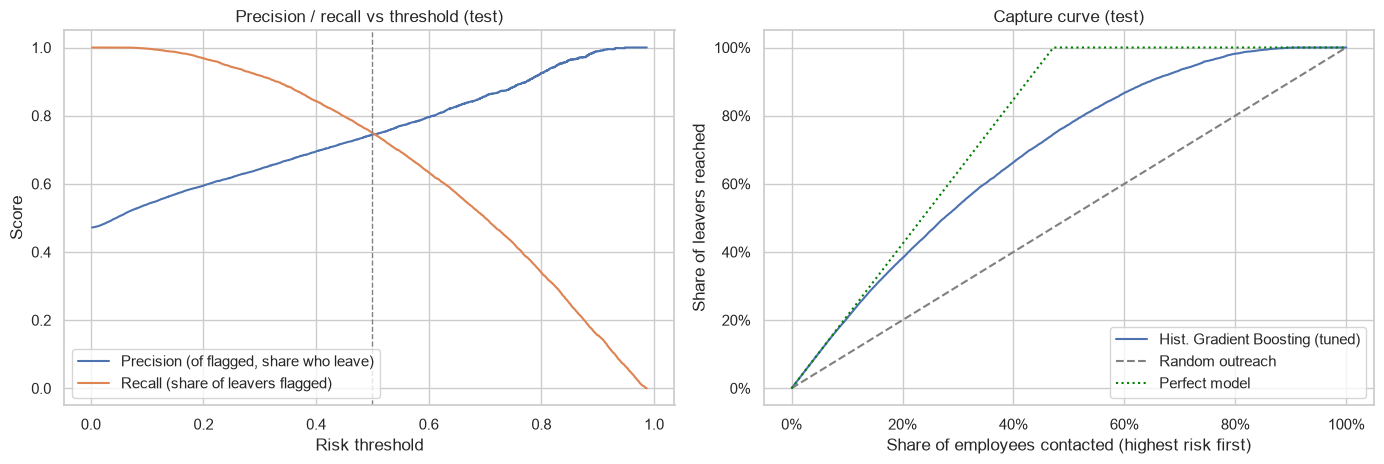

Contact top,Leavers reached,Precision (share of contacted who leave),Lift vs random
10%,20.6%,97.1%,2.06×
20%,38.2%,90.2%,1.91×
30%,53.5%,84.2%,1.78×
50%,77.4%,73.0%,1.55×


In [14]:
prec, rec, thr = precision_recall_curve(y_test, y_score)
order = np.argsort(-y_score)
captured = np.cumsum(y_test.to_numpy()[order]) / y_test.sum()
share = np.arange(1, len(order) + 1) / len(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(thr, prec[:-1], label="Precision (of flagged, share who leave)")
axes[0].plot(thr, rec[:-1], label="Recall (share of leavers flagged)")
axes[0].axvline(0.5, color="grey", ls="--", lw=1)
axes[0].set(xlabel="Risk threshold", ylabel="Score", title="Precision / recall vs threshold (test)")
axes[0].legend(loc="lower left")
axes[1].plot(share, captured, label=f"{best_name} (tuned)")
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", label="Random outreach")
axes[1].plot([0, y_test.mean(), 1], [0, 1, 1], ls=":", color="green", label="Perfect model")
axes[1].set(xlabel="Share of employees contacted (highest risk first)", ylabel="Share of leavers reached",
            title="Capture curve (test)")
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig(ASSETS / "retention_targeting.png", dpi=110, bbox_inches="tight")
plt.show()

budget = pd.DataFrame([
    {"Contact top": f"{k:.0%}", "Leavers reached": captured[int(k * len(order)) - 1],
     "Precision (share of contacted who leave)": y_test.to_numpy()[order][: int(k * len(order))].mean(),
     "Lift vs random": captured[int(k * len(order)) - 1] / k}
    for k in (0.1, 0.2, 0.3, 0.5)
])
budget.style.format({"Leavers reached": "{:.1%}", "Precision (share of contacted who leave)": "{:.1%}", "Lift vs random": "{:.2f}×"}).hide(axis="index")

## 9. Why do employees leave? Global and individual explanations

**Permutation importance** measures how much test ROC-AUC drops when one feature's values are shuffled, so it shows which features the model relies on overall. **SHAP** goes further. It splits each individual prediction into per-feature contributions (in log-odds of leaving) that add up exactly to the model's output. Contributions of one-hot columns are summed back onto their original feature, so "Marital Status" appears as one feature rather than three columns.

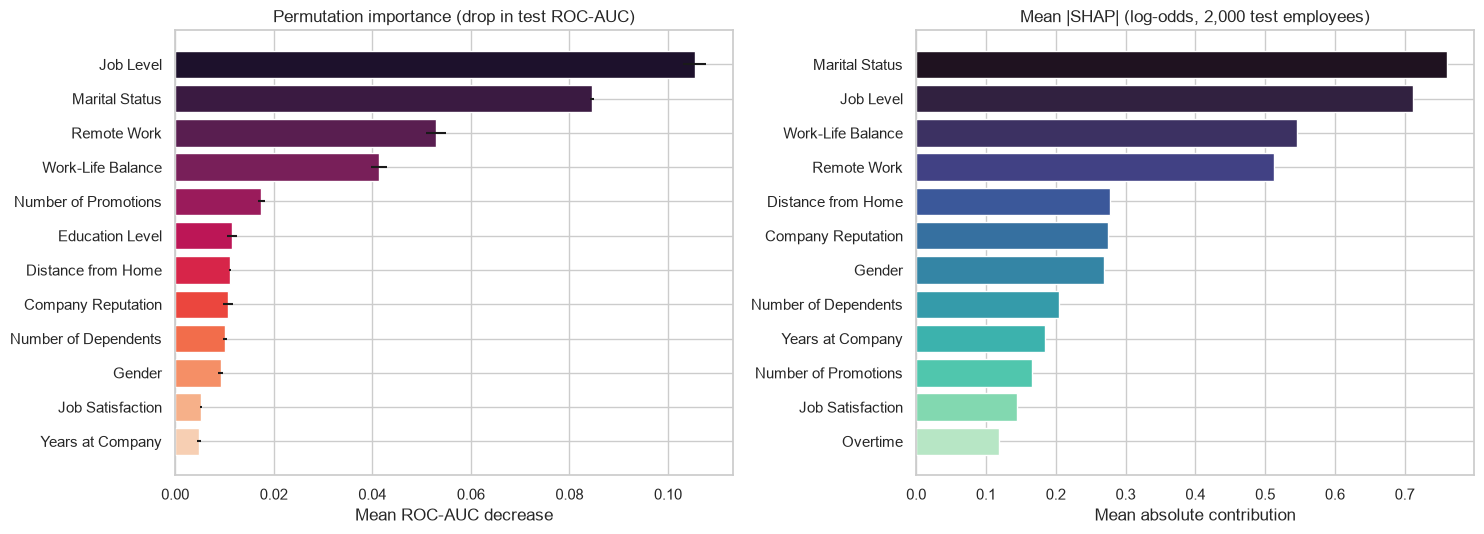

SHAP additivity check: max |base + sum(contributions) - model log-odds| = 1.15e-14


In [15]:
perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=SEED)
importance = (pd.DataFrame({"feature": X_test.columns, "mean": perm.importances_mean, "std": perm.importances_std})
              .sort_values("mean", ascending=False).reset_index(drop=True))

sample = X_test.sample(2000, random_state=SEED)
contrib, base_value = shap_by_feature(final_model, sample)
mean_abs = contrib.abs().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
top = importance.head(12)
axes[0].barh(top["feature"][::-1], top["mean"][::-1], xerr=top["std"][::-1], color=sns.color_palette("rocket", 12)[::-1])
axes[0].set(title="Permutation importance (drop in test ROC-AUC)", xlabel="Mean ROC-AUC decrease")
top_shap = mean_abs.head(12)
axes[1].barh(top_shap.index[::-1], top_shap.values[::-1], color=sns.color_palette("mako", 12)[::-1])
axes[1].set(title="Mean |SHAP| (log-odds, 2,000 test employees)", xlabel="Mean absolute contribution")
plt.tight_layout()
plt.savefig(ASSETS / "feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()

check = base_value + contrib.sum(axis=1) - final_model.decision_function(sample)
print(f"SHAP additivity check: max |base + sum(contributions) - model log-odds| = {np.abs(check).max():.2e}")

### One employee, explained
These are the highest-risk and lowest-risk employees in the sample. Red bars push the prediction towards *leaving* and blue bars towards *staying*.

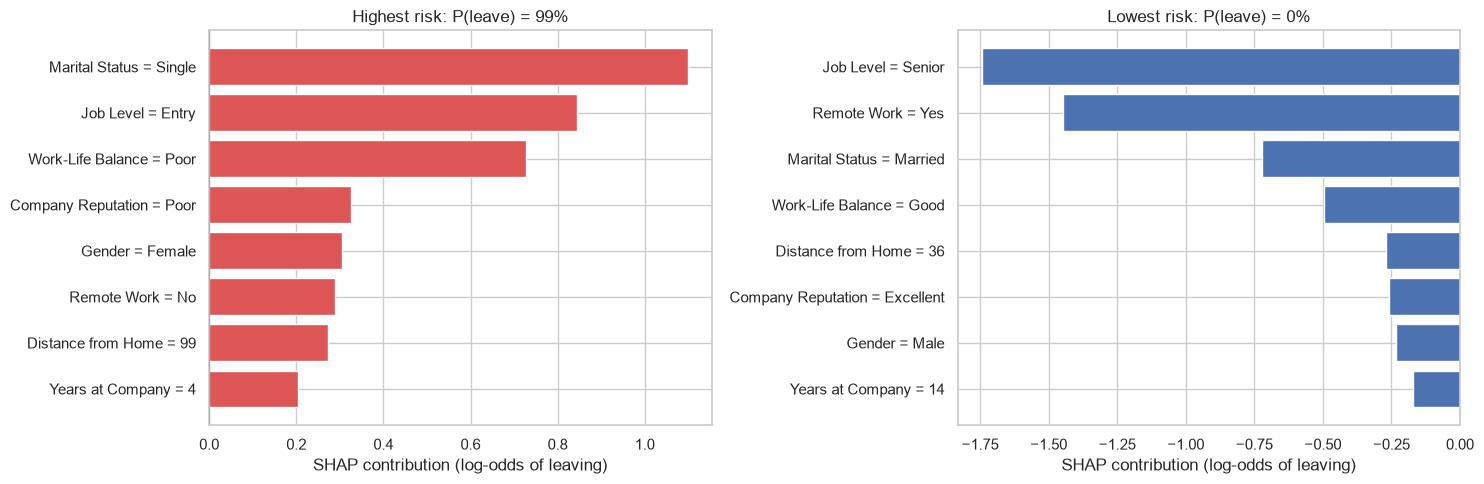

In [16]:
risk = pd.Series(final_model.predict_proba(sample)[:, 1], index=sample.index)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, idx, label in [(axes[0], risk.idxmax(), "Highest risk"), (axes[1], risk.idxmin(), "Lowest risk")]:
    c = contrib.loc[idx]
    c = c.reindex(c.abs().sort_values(ascending=False).index).head(8)[::-1]
    names = [f"{f} = {sample.loc[idx, f]}" for f in c.index]
    ax.barh(names, c.values, color=["#DD5555" if v > 0 else "#4C72B0" for v in c.values])
    ax.axvline(0, color="black", lw=0.8)
    ax.set(title=f"{label}: P(leave) = {risk[idx]:.0%}", xlabel="SHAP contribution (log-odds of leaving)")
plt.tight_layout()
plt.savefig(ASSETS / "individual_explanations.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Fairness audit

**Gender** and **Marital Status** are model inputs, and marital status is one of the strongest drivers. Before a model like this informs decisions about people, the errors it makes should be checked group by group. The table compares each group's actual attrition rate with how often the model flags it (*flag rate*), and the share of real leavers it catches (*TPR*) against the share of stayers it wrongly flags (*FPR*).

In [17]:
pred_s, score_s = pd.Series(y_pred, index=X_test.index), pd.Series(y_score, index=X_test.index)

def group_report(column):
    rows = []
    for group, idx in X_test.groupby(column).groups.items():
        yt, yp, ys = y_test.loc[idx], pred_s.loc[idx], score_s.loc[idx]
        rows.append({"Attribute": column, "Group": group, "Employees": len(idx), "Actual attrition": yt.mean(),
                     "Flag rate": yp.mean(), "TPR": yp[yt == 1].mean(), "FPR": yp[yt == 0].mean(),
                     "ROC-AUC": roc_auc_score(yt, ys)})
    return rows

fairness = pd.DataFrame(group_report("Gender") + group_report("Marital Status"))
fairness.style.format({c: "{:.1%}" for c in ["Actual attrition", "Flag rate", "TPR", "FPR"]} | {"ROC-AUC": "{:.3f}", "Employees": "{:,}"}).hide(axis="index")

Attribute,Group,Employees,Actual attrition,Flag rate,TPR,FPR,ROC-AUC
Gender,Female,"6,813",52.4%,55.1%,79.1%,28.7%,0.845
Gender,Male,"8,087",42.8%,41.1%,70.6%,19.0%,0.855
Marital Status,Divorced,"2,223",41.3%,38.8%,64.4%,20.8%,0.813
Marital Status,Married,"7,511",35.6%,32.3%,61.2%,16.3%,0.833
Marital Status,Single,"5,166",66.6%,73.3%,88.4%,43.4%,0.847


### Ablation: what do the sensitive attributes contribute?
Retrain the tuned model **without Gender and Marital Status**. This shows how much accuracy depends on them, and how much the gaps between groups shrink when the model can no longer use them directly.

In [18]:
blind_nominal = [c for c in NOMINAL if c not in ("Gender", "Marital Status")]
blind_model = make_pipeline(clone(final_model.named_steps["clf"]), nominal=blind_nominal).fit(X_full, y_full)
blind_score = blind_model.predict_proba(X_test)[:, 1]
blind_pred = (blind_score >= 0.5).astype(int)

ablation = []
for name, yp, ys in [("With sensitive attributes", y_pred, y_score), ("Without Gender & Marital Status", blind_pred, blind_score)]:
    rates = {col: pd.Series(yp, index=X_test.index).groupby(X_test[col]).mean() for col in ("Gender", "Marital Status")}
    ablation.append({"Model": name, "Test ROC-AUC": roc_auc_score(y_test, ys),
                     "Flag-rate gap: Gender": rates["Gender"].max() - rates["Gender"].min(),
                     "Flag-rate gap: Marital Status": rates["Marital Status"].max() - rates["Marital Status"].min()})
ablation = pd.DataFrame(ablation)
ablation.style.format({"Test ROC-AUC": "{:.3f}", "Flag-rate gap: Gender": "{:.1%}", "Flag-rate gap: Marital Status": "{:.1%}"}).hide(axis="index")

Model,Test ROC-AUC,Flag-rate gap: Gender,Flag-rate gap: Marital Status
With sensitive attributes,0.852,14.0%,41.0%
Without Gender & Marital Status,0.802,0.3%,1.0%


## 11. Save the model for the demo
The tuned pipeline (preprocessing and model together) is saved with `joblib`. It is loaded by [`app.py`](app.py), and the tests also check it. The pickle is tied to the scikit-learn version, which is recorded next to it and pinned in `requirements.txt`.

In [19]:
joblib.dump(final_model, MODELS / "attrition_model.joblib", compress=3)
card = {"model": f"{best_name} (tuned)", "params": {k: (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()},
        "sklearn_version": sklearn.__version__, "features": FEATURES, "threshold": 0.5,
        "test_metrics": {k: round(float(v), 4) for k, v in final_metrics.items()},
        "risk_bands": {"low": float(np.quantile(y_score, 1 / 3)), "high": float(np.quantile(y_score, 2 / 3))},
        "numeric_ranges": {c: [int(X_full[c].min()), int(X_full[c].max()), int(X_full[c].median())] for c in NUMERIC},
        "categorical_defaults": {c: X_full[c].mode()[0] for c in list(ORDINAL) + list(NOMINAL)}}
(MODELS / "model_card.json").write_text(json.dumps(card, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"saved {MODELS / 'attrition_model.joblib'} ({(MODELS / 'attrition_model.joblib').stat().st_size / 1024:.0f} KB)")
print(json.dumps(card["test_metrics"], indent=2))

saved models\attrition_model.joblib (145 KB)
{
  "Accuracy": 0.7603,
  "ROC-AUC": 0.8523,
  "Precision (Left)": 0.7445,
  "Recall (Left)": 0.7493,
  "F1 (Left)": 0.7469
}


## 12. Takeaways

In [20]:
gaps = fairness.groupby("Attribute")[["Flag rate", "TPR", "FPR"]].agg(lambda s: s.max() - s.min())
top20 = budget.iloc[1]
print(f"Final model             : {best_name} (tuned)")
print(f"Test accuracy / ROC-AUC : {final_metrics['Accuracy']:.3f} / {final_metrics['ROC-AUC']:.3f}")
print(f"Top-5 drivers (SHAP)    : {', '.join(mean_abs.index[:5])}")
print(f"Contact top 20% by risk : reaches {top20['Leavers reached']:.0%} of leavers ({top20['Lift vs random']:.2f}× random)")
print(f"Flag-rate gap, gender   : {gaps.loc['Gender', 'Flag rate']:.1%}  | marital status: {gaps.loc['Marital Status', 'Flag rate']:.1%}")
print(f"ROC-AUC without Gender & Marital Status: {ablation.loc[1, 'Test ROC-AUC']:.3f} (vs {ablation.loc[0, 'Test ROC-AUC']:.3f})")

Final model             : Hist. Gradient Boosting (tuned)
Test accuracy / ROC-AUC : 0.760 / 0.852
Top-5 drivers (SHAP)    : Marital Status, Job Level, Work-Life Balance, Remote Work, Distance from Home
Contact top 20% by risk : reaches 38% of leavers (1.91× random)
Flag-rate gap, gender   : 14.0%  | marital status: 41.0%
ROC-AUC without Gender & Marital Status: 0.802 (vs 0.852)


- **Tuned gradient boosting reaches 76.0% accuracy and 0.852 ROC-AUC on the untouched test set.** Tuning added very little over the defaults (CV ROC-AUC 0.8495 vs 0.849 validation), so the data limits the model more than the hyperparameters do. Logistic regression is only about 2 points behind.
- **As a retention tool, the scores are useful.** Contacting the 20% of employees with the highest risk reaches 38% of all leavers, and 90% of the people contacted really do leave. That is 1.9× better than random outreach.
- **Drivers:** marital status, job level, work-life balance and remote work dominate, both in permutation importance and in SHAP. **Pay, overtime and job satisfaction matter surprisingly little** in this data.
- **Fairness: the model amplifies existing group differences.** Women are flagged 55% of the time against an actual attrition rate of 52%, while men are flagged 41% against 43%. Single employees are flagged 73% against 67%. The false-positive rate is 29% for women vs 19% for men, and 43% for single vs 16% for married employees. Stayers in those groups are much more likely to be wrongly labelled as flight risks.
- **Removing Gender and Marital Status is not free.** It costs 5 points of ROC-AUC (0.852 → 0.802) and nearly closes the flag-rate gaps (14 → 0.3 points by gender, 41 → 1 by marital status). The groups really do differ in attrition rate here, so which version is "right" is a policy choice, not a modelling one. Real HR data would also need checks for **proxy features** that could reintroduce the same signal.
- **Limitations:** the data is synthetic, so the drivers and gaps describe this generator rather than a real workforce.